# RidgeClassifier

In [1]:
import pandas as pd
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('weather_data.csv')
df.head()

,City,Temperature (Celsius),Wind Speed (m/s),Latitude,Longitude,Description,Country
0,Paris,10.46,2.06,48.8534,2.3488,clear sky,France
1,Dubai,29.32,3.09,25.2582,55.3047,clear sky,United Arab Emirates
2,Madrid,9.97,3.60,40.4165,-3.7026,clear sky,Spain
3,Tokyo,21.58,2.06,35.6895,139.6917,broken clouds,Japan
4,Amsterdam,8.00,3.58,52.3740,4.8897,clear sky,Netherlands


In [3]:
df.tail()

,City,Temperature (Celsius),Wind Speed (m/s),Latitude,Longitude,Description,Country
95,Punta Cana,26.87,6.69,18.5818,-68.4043,few clouds,Dominican Republic
96,Guilin,24.06,0.97,25.2819,110.2864,clear sky,China
97,Hanoi,28.00,2.49,21.0245,105.8412,clear sky,Vietnam
98,Cairo,19.42,4.63,30.0626,31.2497,clear sky,Egypt
99,Muscat,28.01,2.76,23.6139,58.5922,broken clouds,Oman


In [4]:
df.isnull().sum()

City                     0
Temperature (Celsius)    0
Wind Speed (m/s)         0
Latitude                 0
Longitude                0
Description              0
Country                  0
dtype: int64

In [5]:
df=df.drop_duplicates()

In [6]:
df['Description'].value_counts()

Description
clear sky               40
scattered clouds        15
broken clouds           13
overcast clouds         10
few clouds               9
light rain               6
shower rain              1
mist                     1
moderate rain            1
heavy intensity rain     1
fog                      1
haze                     1
smoke                    1
Name: count, dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   100 non-null    object 
 1   Temperature (Celsius)  100 non-null    float64
 2   Wind Speed (m/s)       100 non-null    float64
 3   Latitude               100 non-null    float64
 4   Longitude              100 non-null    float64
 5   Description            100 non-null    object 
 6   Country                100 non-null    object 
dtypes: float64(4), object(3)
memory usage: 5.6+ KB


In [8]:

# Transform the columns value(ex: int to str, str to int) for classification purpose.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

var = ['City','Description','Country']
  
for i in var:
    df[i] = le.fit_transform(df[i]).astype(int)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   City                   100 non-null    int32  
 1   Temperature (Celsius)  100 non-null    float64
 2   Wind Speed (m/s)       100 non-null    float64
 3   Latitude               100 non-null    float64
 4   Longitude              100 non-null    float64
 5   Description            100 non-null    int32  
 6   Country                100 non-null    int32  
dtypes: float64(4), int32(3)
memory usage: 4.4 KB


In [10]:
x1=df.drop('Description',axis=1)
y1=df['Description']

In [11]:
import imblearn
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

ros =RandomOverSampler(random_state=42)
x,y=ros.fit_resample(x1,y1)
print("OUR DATASET COUNT         : ", Counter(y1))
print("OVER SAMPLING DATA COUNT  : ", Counter(y))

OUR DATASET COUNT         :  Counter({1: 40, 10: 15, 0: 13, 9: 10, 2: 9, 6: 6, 11: 1, 7: 1, 8: 1, 5: 1, 3: 1, 4: 1, 12: 1})
OVER SAMPLING DATA COUNT  :  Counter({1: 40, 0: 40, 11: 40, 10: 40, 9: 40, 6: 40, 2: 40, 7: 40, 8: 40, 5: 40, 3: 40, 4: 40, 12: 40})


In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,stratify=y)
print("NUMBER OF TRAIN DATASET    : ", len(x_train))
print("NUMBER OF TEST DATASET      : ", len(x_test))
print("TOTAL NUMBER OF DATASET    : ", len(x_train)+len(x_test))

NUMBER OF TRAIN DATASET    :  390
NUMBER OF TEST DATASET      :  130
TOTAL NUMBER OF DATASET    :  520


In [13]:
print("NUMBER OF TRAIN DATASET    : ", len(y_train))
print("NUMBER OF TEST DATASET      : ", len(y_test))
print("TOTAL NUMBER OF DATASET    : ", len(y_train)+len(y_test))

NUMBER OF TRAIN DATASET    :  390
NUMBER OF TEST DATASET      :  130
TOTAL NUMBER OF DATASET    :  520


In [14]:
from sklearn.linear_model import RidgeClassifier

In [15]:
ada=RidgeClassifier()

ada.fit(x_train,y_train)

RidgeClassifier()

In [16]:
# Predict is the test function for this algorithm
test=ada.predict(x_test)


In [17]:
# Check the cross value score of this algorithm.
from sklearn.model_selection import cross_val_score
accuracy = cross_val_score(ada,x, y, scoring='accuracy')
print('THE CROSS VALIDATION TEST RESULT OF ACCURACY :\n\n\n', accuracy*100)

THE CROSS VALIDATION TEST RESULT OF ACCURACY :


 [65.38461538 64.42307692 63.46153846 68.26923077 64.42307692]


In [18]:
# Check the confusion matrix for this algorithms
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test,y_test)
print('THE CONFUSION MATRIX SCORE OF RidgeClassifier:\n\n\n',cm)

THE CONFUSION MATRIX SCORE OF RidgeClassifier:


 [[ 0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 2  0  0 10  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0 10  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 10  0  0  0  0  0  0  0]
 [ 0  1  2  0  0  0  7  0  0  0  1  0  0]
 [ 2  1  2  0  0  0  2 10  0  0  5  0  0]
 [ 2  1  0  0  0  0  0  0 10  2  0  0  0]
 [ 2  3  2  0  0  0  1  0  0  8  2  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  1  0  0  0  0  0  0  0  1 10  0]
 [ 2  1  2  0  0  0  0  0  0  0  1  0 10]]


In [19]:
# Check the accuracy score of this algorithms.
from sklearn.metrics import accuracy_score
a = accuracy_score(y_test,test)
print("THE ACCURACY SCORE OF RidgeClassifier IS :",a*100)

THE ACCURACY SCORE OF RidgeClassifier IS : 66.15384615384615


In [20]:
# Check the hamming loss of this algorithm.
from sklearn.metrics import hamming_loss
hl = hamming_loss(y_test,test)
print("THE HAMMING LOSS OF RidgeClassifier IS :",hl*100)

THE HAMMING LOSS OF RidgeClassifier IS : 33.84615384615385


In [21]:
# Check classification report for this algorithm
from sklearn.metrics import classification_report
cr = classification_report(y_test,test)
print('THE CLASSIFICATION REPORT OF RidgeClassifier:\n\n',cr)

THE CLASSIFICATION REPORT OF RidgeClassifier:

               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.00      0.00      0.00        10
           2       1.00      0.10      0.18        10
           3       0.83      1.00      0.91        10
           4       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        10
           6       0.64      0.70      0.67        10
           7       0.45      1.00      0.62        10
           8       0.67      1.00      0.80        10
           9       0.44      0.80      0.57        10
          10       0.00      0.00      0.00        10
          11       0.77      1.00      0.87        10
          12       0.62      1.00      0.77        10

    accuracy                           0.66       130
   macro avg       0.56      0.66      0.56       130
weighted avg       0.56      0.66      0.56       130



THE CONFUSION MATRIX SCORE OF RidgeClassifier:


[[ 0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 2  0  0 10  0  0  0  0  0  0  0  0  0]
 [ 0  2  0  0 10  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 10  0  0  0  0  0  0  0]
 [ 0  1  2  0  0  0  7  0  0  0  1  0  0]
 [ 2  1  2  0  0  0  2 10  0  0  5  0  0]
 [ 2  1  0  0  0  0  0  0 10  2  0  0  0]
 [ 2  3  2  0  0  0  1  0  0  8  2  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  1  0  0  0  0  0  0  0  1 10  0]
 [ 2  1  2  0  0  0  0  0  0  0  1  0 10]]


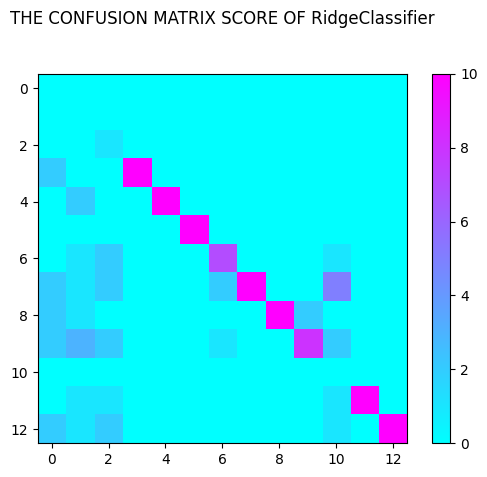

In [22]:
# Plot a Confusion matrix for this algorithms.
import matplotlib.pyplot as plt
def plot_confusion_matrix(cm, title='THE CONFUSION MATRIX SCORE OF RidgeClassifier\n\n', cmap=plt.cm.cool):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

cm1=confusion_matrix(y_test, test)
print('THE CONFUSION MATRIX SCORE OF RidgeClassifier:\n\n')
print(cm)
plot_confusion_matrix(cm)

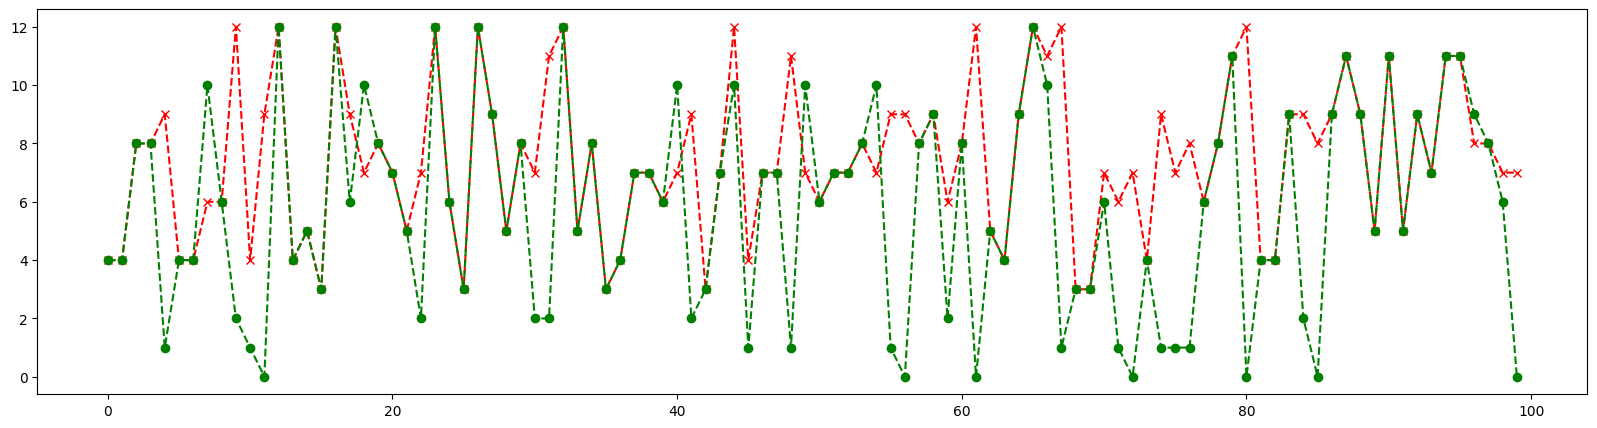

In [23]:
# Plot the worm plot for this model.
import matplotlib.pyplot as plt
df2 = pd.DataFrame()
df2["y_test"] = y_test
df2["test"] = test
df2.reset_index(inplace=True)
plt.figure(figsize=(20, 5))
plt.plot(df2["test"][:100], marker='x', linestyle='dashed', color='red')
plt.plot(df2["y_test"][:100],  marker='o', linestyle='dashed', color='green')
plt.show()